In [1]:
import pandas as pd

df = pd.read_csv("df_model_hazır3.csv")

print(df.columns)
print(df["Severity_num"].value_counts())


Index(['Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles',
       'Speed_limit', 'Urban_or_Rural_Area', 'Year', 'Month', 'Day', 'Weekday',
       'Hour', 'Is_Rush_Hour', 'Is_Weekend', 'Is_Night', 'Bad_Road_Condition',
       'Bad_Weather', 'Day_Monday', 'Day_Saturday', 'Day_Sunday',
       'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Road_Type_One way street',
       'Road_Type_Roundabout', 'Road_Type_Single carriageway',
       'Road_Type_Slip road', 'Vehicle_Group_Goods',
       'Vehicle_Group_Motorcycle', 'Vehicle_Group_Other',
       'Vehicle_Group_Public', 'Vehicle_Group_Vulnerable',
       'Junction_Control_Grouped_No_Junction',
       'Junction_Control_Grouped_Sign_Controlled',
       'Junction_Control_Grouped_Unknown',
       'Junction_Detail_Grouped_No_Junction',
       'Junction_Detail_Grouped_Roundabout',
       'Junction_Detail_Grouped_Simple_Junction', 'Severity_num',
       'Speed_Category_Me

In [6]:
# =========================
# Random Forest + Undersampling (Majority azaltma) - DÜZENLENMİŞ TAM KOD
# =========================

import numpy as np
import pandas as pd

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler


# -------------------------
# 1) VERİ HAZIRLAMA
# -------------------------
# df: senin dataframe'in
TARGET_COL = "Severity_num"   # <-- sende hedef bu olmalı (0,1,2)
DROP_COLS = []               # <-- istemediğin kolonlar varsa buraya ekle

# Hedef + özellikler
if TARGET_COL not in df.columns:
    raise ValueError(f"TARGET_COL bulunamadı: {TARGET_COL}. df.columns içinde var mı kontrol et.")

y = df[TARGET_COL].astype(int)
X = df.drop(columns=[TARGET_COL] + DROP_COLS, errors="ignore")

# Bool kolonları 0/1'e çevir (RF daha net sever)
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Kategorik varsa one-hot encode
cat_cols = X.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Inf / NaN temizliği
X = X.replace([np.inf, -np.inf], np.nan)

# Sayısalları median ile doldur
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Hala NaN kaldıysa (çok nadir), 0 bas
X = X.fillna(0)

print("✅ X shape:", X.shape)
print("✅ y dağılımı:", Counter(y))


# -------------------------
# 2) TRAIN / TEST SPLIT (Stratify)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nOrijinal Train Dağılımı:", Counter(y_train))
print("Orijinal Test  Dağılımı:", Counter(y_test))


# -------------------------
# 3) UNDERSAMPLING (baskın sınıfı azalt)
# -------------------------
train_counts = Counter(y_train)

# Baskın sınıfı kaça indirelim?
MAJORITY_TARGET = 50_000  # istersen 30_000 de yapabiliriz

majority_class = max(train_counts, key=train_counts.get)

sampling_strategy = {}
for cls, cnt in train_counts.items():
    if cls == majority_class:
        sampling_strategy[cls] = min(MAJORITY_TARGET, cnt)
    else:
        sampling_strategy[cls] = cnt  # diğer sınıflar aynı kalsın

print("\nSampling Strategy:", sampling_strategy)

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print("Undersampling sonrası Train Dağılımı:", Counter(y_train_res))


# -------------------------
# 4) RANDOM FOREST EĞİTİMİ
# -------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",   # istersek bunu kapatıp da deneriz
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)


# -------------------------
# 5) TAHMİN + DEĞERLENDİRME
# -------------------------
y_pred = rf.predict(X_test)

print("\n=== Classification Report (macro önemli) ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

bal_acc = balanced_accuracy_score(y_test, y_pred)
print("=== Balanced Accuracy ===")
print(bal_acc)


# -------------------------
# 6) FEATURE IMPORTANCE TOP 20
# -------------------------
feature_names = X_train_res.columns  # ✅ doğru kolon listesi (dummies sonrası)
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\n=== Top 20 Feature Importance ===")
print(importances.head(20))


✅ X shape: (307973, 42)
✅ y dağılımı: Counter({0: 263280, 1: 40740, 2: 3953})

Orijinal Train Dağılımı: Counter({0: 210624, 1: 32592, 2: 3162})
Orijinal Test  Dağılımı: Counter({0: 52656, 1: 8148, 2: 791})

Sampling Strategy: {1: 32592, 0: 50000, 2: 3162}
Undersampling sonrası Train Dağılımı: Counter({0: 50000, 1: 32592, 2: 3162})

=== Classification Report (macro önemli) ===
              precision    recall  f1-score   support

           0     0.9017    0.6739    0.7713     52656
           1     0.2008    0.5260    0.2907      8148
           2     0.1034    0.1176    0.1101       791

    accuracy                         0.6472     61595
   macro avg     0.4020    0.4392    0.3907     61595
weighted avg     0.7988    0.6472    0.6993     61595

=== Confusion Matrix ===
[[35485 16562   609]
 [ 3665  4286   197]
 [  202   496    93]]
=== Balanced Accuracy ===
0.43916455233567925

=== Top 20 Feature Importance ===
Latitude                               0.134113
Longitude             

===== FINAL MODEL: RandomForest + Undersampling =====
Accuracy: 0.647
Macro F1: 0.391
Weighted F1: 0.699
Macro Precision: 0.402
Macro Recall: 0.439

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9017    0.6739    0.7713     52656
           1     0.2008    0.5260    0.2907      8148
           2     0.1034    0.1176    0.1101       791

    accuracy                         0.6472     61595
   macro avg     0.4020    0.4392    0.3907     61595
weighted avg     0.7988    0.6472    0.6993     61595


--- Confusion Matrix (rows=true, cols=pred) ---
[[35485 16562   609]
 [ 3665  4286   197]
 [  202   496    93]]


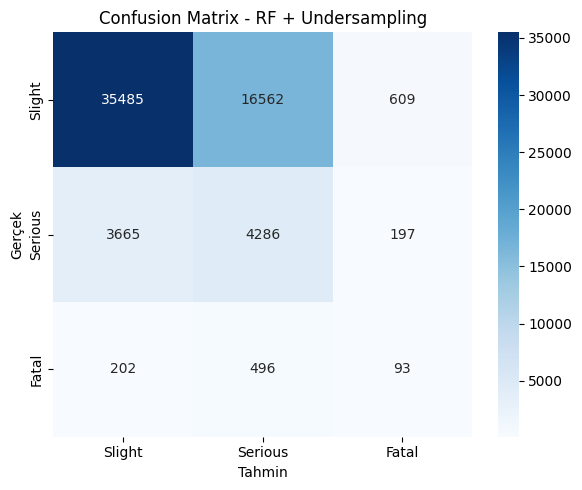

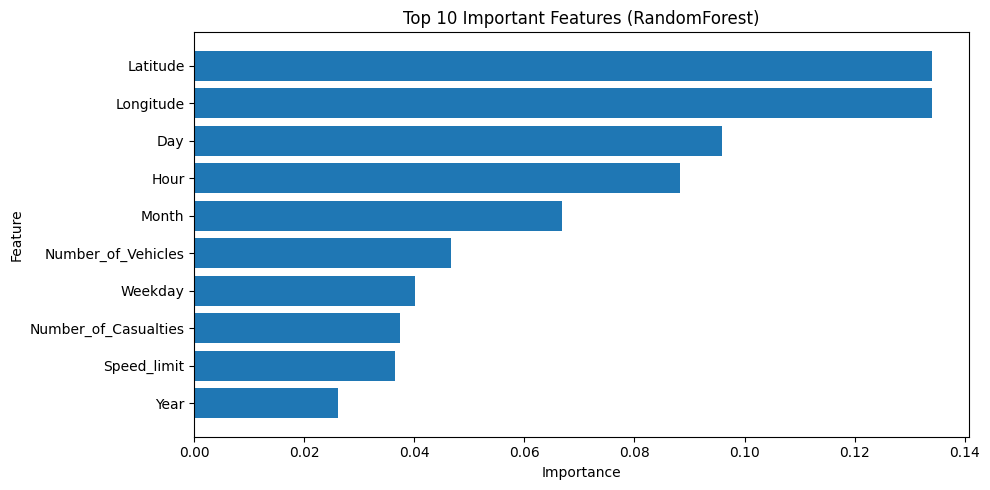

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

# --- 1) Metrikleri tek blok yazdır ---
print("===== FINAL MODEL: RandomForest + Undersampling =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 3))
print("Weighted F1:", round(f1_score(y_test, y_pred, average="weighted"), 3))
print("Macro Precision:", round(precision_score(y_test, y_pred, average="macro", zero_division=0), 3))
print("Macro Recall:", round(recall_score(y_test, y_pred, average="macro", zero_division=0), 3))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

# --- 2) Confusion Matrix: hem sayı hem heatmap ---
cm = confusion_matrix(y_test, y_pred)

print("\n--- Confusion Matrix (rows=true, cols=pred) ---")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix - RF + Undersampling")
plt.tight_layout()
plt.show()

# --- 3) Top 10 Feature Importance bar chart ---
importances = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)
top10 = importances.head(10).sort_values()  # küçükten büyüğe (görsel daha güzel)

plt.figure(figsize=(10,5))
plt.barh(top10.index, top10.values)
plt.title("Top 10 Important Features (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
